<a href="https://colab.research.google.com/github/eSeohyeon/Python_for_CV/blob/main/5_%EA%B5%AC%EA%B8%80%EB%84%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 텐서플로를 활용한 구글넷 구현

import tensorflow as tf
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D, BatchNormalization, Activation, Input, AveragePooling2D, concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


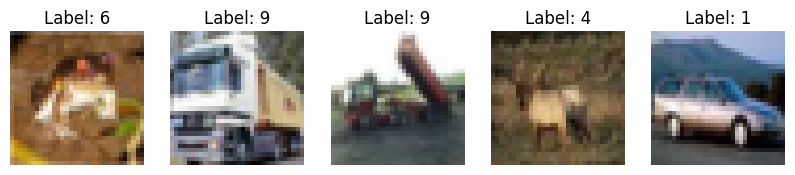

In [2]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()
num_classes = 10

plt.figure(figsize=(10, 2))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(train_x[i])
  plt.title(f"Label: {train_y[i][0]}")
  plt.axis('off')
plt.show()

In [15]:
print(f"스케일링 전 픽셀의 최댓값과 최솟값 : {train_x.min()} ~ {train_x.max()}")
train_x = train_x/255.
test_x = test_x/255.
print(f"스케일링 후 픽셀의 최댓값과 최솟값 : {train_x.min()} ~ {train_x.max()}")

스케일링 전 픽셀의 최댓값과 최솟값 : 0.0 ~ 1.0
스케일링 후 픽셀의 최댓값과 최솟값 : 0.0 ~ 0.00392156862745098


In [14]:
image_size = (32, 32)
batch_size = 64
weight_decay = 5e-4
learning_rate = 1e-2
epochs = 40

In [13]:
def conv2d_bn_relu(x, filters, kernel_size, weight_decay=.0, strides = 1):
  x = Conv2D(
      filters = filters,
      kernel_size = kernel_size,
      strides=strides,
      padding = 'same',
      kernel_regularizer = regularizers.l2(weight_decay)
  )(x)
  x = BatchNormalization(scale=False, axis=3)(x)
  x = Activation('relu')(x)
  return x

def inception_module(x, filters_num_array, weight_decay=.0):
  (br0_filters, br1_filters, br2_filters, br3_filters) = filters_num_array
  br0= conv2d_bn_relu(x, filters=br0_filters, kernel_size=1, weight_decay=weight_decay)
  br1=conv2d_bn_relu(x, filters=br1_filters[0], kernel_size=1, weight_decay=weight_decay)
  br1=conv2d_bn_relu(br1, filters=br1_filters[1], kernel_size=3, weight_decay=weight_decay)
  br2=conv2d_bn_relu(x, filters=br2_filters[0], kernel_size=1, weight_decay=weight_decay)
  br2=conv2d_bn_relu(br2, filters=br2_filters[1], kernel_size=5)
  br3=MaxPool2D(pool_size=3, strides=(1, 1), padding = 'same')(x)
  br3=conv2d_bn_relu(br3, filters=br3_filters, kernel_size=1, weight_decay=weight_decay)
  x = concatenate([br0, br1, br2, br3], axis = 3)
  return x

def googlenet(input_shape, classes, weight_decay=.0):
  input = Input(shape=input_shape)
  x = input
  x = conv2d_bn_relu(x, filters=64, kernel_size=1, weight_decay=weight_decay)
  x=conv2d_bn_relu(x, filters=192, kernel_size=3, weight_decay=weight_decay)
  x=MaxPool2D(pool_size=3, strides=2, padding='same')(x)
  x=inception_module(x, (64, (96, 128), (16,32), 32), weight_decay=weight_decay)
  x=inception_module(x, (128, (128,192), (32, 96), 64), weight_decay = weight_decay)
  x = MaxPool2D(pool_size=2, strides=2, padding='same')(x)
  x=inception_module(x, (192, (96, 208), (16, 48), 64), weight_decay = weight_decay)
  x=inception_module(x, (160, (112,224), (24, 64), 64), weight_decay=weight_decay)
  x=inception_module(x, (128, (128,256), (24, 64), 64), weight_decay=weight_decay)
  x=inception_module(x, (112, (144, 288), (32, 64), 64), weight_decay=weight_decay)
  x=inception_module(x, (256, (160, 320), (32, 128), 128), weight_decay = weight_decay)
  x=MaxPool2D(pool_size=2, strides=2, padding='same')(x)
  x=inception_module(x, (256, (160, 320), (32, 128), 128), weight_decay=weight_decay)
  x=inception_module(x, (384, (192, 384), (48, 128), 128), weight_decay=weight_decay)
  x=AveragePooling2D(pool_size=4, strides=1, padding='valid')(x)
  x=Flatten(name='flatten')(x)
  output=Dense(classes, activation='softmax')(x)
  model=Model(input, output)
  return model

In [16]:
googlenet = googlenet(input_shape = (image_size[0], image_size[1], 3), classes = num_classes, weight_decay = weight_decay)
optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate, momentum = 0.9)
googlenet.compile(optimizer = optimizer, loss ='sparse_categorical_crossentropy', metrics = ['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 4, min_lr = 1e-7, verbose = 1)
history = googlenet.fit(
    x = train_x,
    y = train_y,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.2,
    callbacks = [reduce_lr]
)

Epoch 1/40


KeyboardInterrupt: 

NameError: name 'history' is not defined

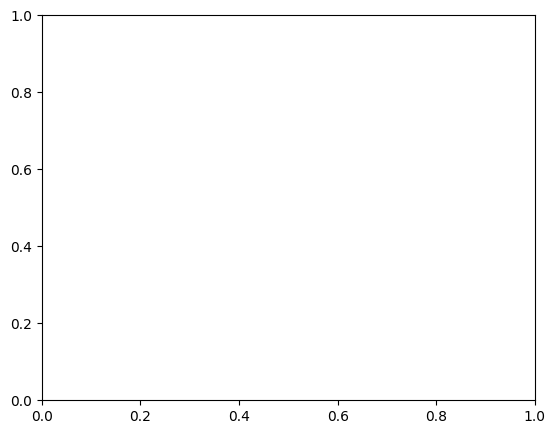

In [3]:
plt.figure(figsize = (14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title("Training and Vvalidation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

In [4]:
googlenet.evaluate(test_x, test_y)

NameError: name 'googlenet' is not defined